# Hands-On Module 1, Exploratory Data Analysis: Spotify Songs Dataset

Nama: Jonathan Lewie
NIM: 13525136
Dataset: Spotify Songs (TidyTuesday 2020), audio features ~30rb lagu, 6 genre playlist
Tools: Python, Pandas, NumPy, Matplotlib/Seaborn, + bantuan AI coding tool (Gemini / GitHub Copilot) untuk dokumentasi

Tujuan notebook ini adalah melakukan EDA terstruktur sebelum menyentuh model apa pun. Idenya sederhana, sebelum bikin model rekomendasi/prediksi, kita harus benar-benar paham dulu datanya dimana bentuknya seperti apa, ada yang kotor/hilang tidak, dan pola apa yang sudah kelihatan. Prinsip yang saya pegang adalah *garbage in, garbage out*. Kalau tahap ini dilewat, model bagus pun hasilnya nggak bisa dipercaya.

In [1]:
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


## Stage 1, Setup dan Inspeksi Awal

Langkah paling awal adalah load data langsung dari URL, lalu kenali bentuk datanya sebelum ngapa-ngapain.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
SPOTIFY_GREEN = "#1DB954"
URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(URL)
print("Shape:", df.shape)
df.head()

Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


### 1.2 Inspeksi awal untuk shape, dtypes, dan missing value

Setelah load, hal pertama yang selalu saya lakukan adalah cek `shape`, tipe data tiap kolom, dan berapa banyak yang kosong. Aturan tugasnya, kalau ada kolom dengan missing > 20%, kolomnya di drop dan dikasih alasan.

In [2]:
print("SHAPE:")
print(df.shape, "->", df.shape[0], "baris,", df.shape[1], "kolom")
print("\nDTYPES: ")
print(df.dtypes)
print("\nMISSING VALUE per kolom: ")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_tbl = pd.DataFrame({"jumlah_null": missing, "persen_null": missing_pct.round(2)})
print(missing_tbl[missing_tbl["jumlah_null"] > 0])   # tampilkan yang ada null saja

SHAPE:
(32833, 23) -> 32833 baris, 23 kolom

DTYPES: 
track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

MISSING VALUE per kolom: 
                  jumlah_null  persen_null
track_name                  5     

Yang punya missing value cuma 3 kolom yaitu `track_name`, `track_artist`, `track_album_name`, masing-masing 5 baris dari ~32.800. Itu cuma sekitar 0.015%, jauh banget di bawah 20%. Jadi nggak ada kolom yang perlu di-drop. Kolom numerik (audio features + popularity) semuanya lengkap tanpa null, kolom-kolom itu yang bakal dipakai analisis kuantitatif.

5 baris yang track_artist nya kosong nanti aman diabaikan untuk analisis numerik, kalau butuh analisis per-artist, baris itu tinggal di skip saja.

### 1.3 Duplikat

Ini bagian yang menurut saya paling gampang salah kalau nggak teliti. Saya cek dua hal yaitu duplikat baris penuh (semua kolom identik) dan duplikat berdasarkan `track_id`.

In [3]:
print("Duplikat baris penuh (semua kolom sama):", df.duplicated().sum())
print("Duplikat berdasarkan track_id       :", df.duplicated(subset=["track_id"]).sum())
print("track_id unik:", df["track_id"].nunique(), "dari", len(df), "baris")

Duplikat baris penuh (semua kolom sama): 0
Duplikat berdasarkan track_id       : 4477
track_id unik: 28356 dari 32833 baris


Duplikat baris penuh = 0, tapi kalau dicek dari `track_id` ada 4477 duplikat. Kenapa bisa begitu? Karena dataset ini basisnya playlist, bukan lagu. Satu lagu yang sama bisa masuk ke banyak playlist berbeda, jadi muncul berkali-kali dengan `track_id` yang sama tapi `playlist_name`/`playlist_genre` beda.

Untuk analisis yang unit nya adalah lagu (statistik audio feature, popularitas per lagu, korelasi), lagu yang sama nggak boleh dihitung berkali-kali, nanti lagu populer yang kebetulan masuk 10 playlist jadi keliatan "10x lebih penting" padahal cuma satu lagu. Makanya saya dedup pakai `track_id` (bukan `track_name`, karena bisa ada dua lagu beda judulnya sama), dan ambil kemunculan pertama.

Konsekuensi yang saya sadari yaitu dengan dedup ini, tiap lagu jadi kehilangan info bahwa dia ada di beberapa genre. Tapi untuk EDA audio feature ini trade off yang wajar, 1 lagu = 1 baris jauh lebih benar secara statistik.

In [4]:
df_clean = df.drop_duplicates(subset=["track_id"], keep="first").reset_index(drop=True)
print("Sebelum:", df.shape[0], "baris")
print("Sesudah :", df_clean.shape[0], "baris")
print("Terhapus:", df.shape[0] - df_clean.shape[0], "baris duplikat lagu")

Sebelum: 32833 baris
Sesudah : 28356 baris
Terhapus: 4477 baris duplikat lagu


### 1.4 Tabel ringkasan mean, median, std, dan IQR (IQR manual pakai NumPy)

Tugas minta IQR dihitung manual pakai NumPy (nggak boleh scipy). IQR = Q3 − Q1, jadi tinggal `np.percentile` di 75 dan 25. IQR ini berguna karena lebih tahan outlier dibanding std, jadi bisa saya bandingkan sama std untuk lihat kolom mana yang distribusinya aneh.

In [5]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
rows = []
for c in num_cols:
    vals = df_clean[c].dropna().to_numpy(dtype=float)
    q1, q3 = np.percentile(vals, [25, 75])
    rows.append({
        "column": c,
        "mean":   vals.mean(),
        "median": np.median(vals),
        "std":    vals.std(),
        "IQR":    q3 - q1,
    })

summary = pd.DataFrame(rows).set_index("column").round(3)
summary

,mean,median,std,IQR
column,,,,
track_popularity,39.330,42.000,23.702,37.000
danceability,0.653,0.670,0.146,0.199
energy,0.698,0.722,0.183,0.264
key,5.368,6.000,3.614,7.000
loudness,-6.818,-6.261,3.036,3.600
mode,0.565,1.000,0.496,1.000
speechiness,0.108,0.063,0.103,0.092
acousticness,0.177,0.080,0.223,0.246
instrumentalness,0.091,0.000,0.233,0.007


Pembacaan cepat tabelnya adalah sebagai berikut.

- `track_popularity` mean ~39 tapi std ~24 dan IQR 37, sebarannya lebar banget, artinya popularitas lagu benar-benar variatif (ada yang 0, ada yang mendekati 100). Ini penting karena kalau nanti dijadikan target model, distribusinya nggak sempit.
- `duration_ms` pasti punya angka gede (skalanya milidetik), ini jadi alarm buat Stage 3 dimana kalau fitur digabung tanpa normalisasi, kolom berskala besar bakal mendominasi.
- Fitur audio (danceability, energy, valence, dll) rata-rata di rentang 0–1, jadi relatif seragam kecuali `tempo` dan `loudness`.

Biar klaim "popularitas sebarannya lebar", saya plot histogramnya di bawah.

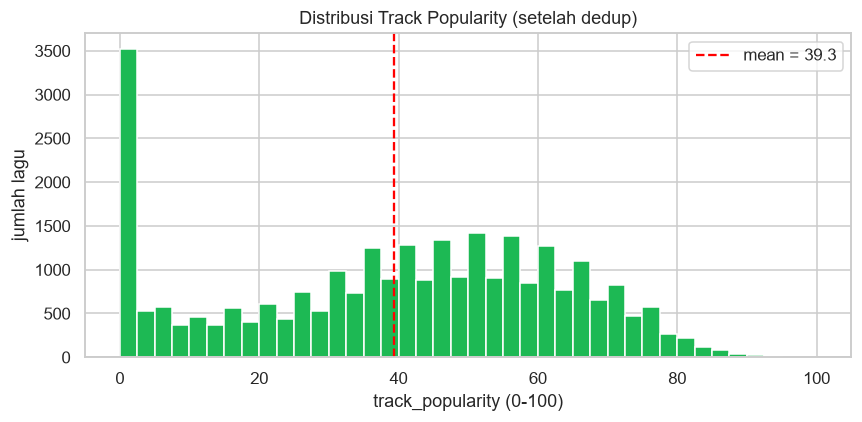

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean["track_popularity"], bins=40, color=SPOTIFY_GREEN, edgecolor="white")
mean_pop = df_clean["track_popularity"].mean()
plt.axvline(mean_pop, color="red", linestyle="--", linewidth=1.5, label=f"mean = {mean_pop:.1f}")
plt.title("Distribusi Track Popularity (setelah dedup)")
plt.xlabel("track_popularity (0-100)")
plt.ylabel("jumlah lagu")
plt.legend()
plt.tight_layout()
plt.show()

Kelihatan jelas kalau ada tumpukan besar di popularity = 0 (banyak lagu yang praktis nggak didengerin sama sekali), lalu sisanya nyebar sampai ke 90an. Distribusinya nggak normal dan agak bimodal. Ini catatan penting kalau nanti popularity dijadikan target, mungkin perlu perlakuan khusus buat lagu ber popularity 0.

## Stage 2, Analisis Genre dan Popularitas

### 2.5 Statistik distribusi per genre (groupby)

Saya pakai `groupby("playlist_genre")` lalu `.agg(["mean","std","median"])` untuk 4 kolom sekaligus. Ini cara paling ringkas lihat karakter tiap genre dalam satu tabel.

In [7]:
dist = (df_clean.groupby("playlist_genre")[["track_popularity", "danceability", "energy", "valence"]].agg(["mean", "std", "median"]).round(3))
dist

track_popularity                danceability                \
                           mean     std median         mean    std median   
playlist_genre                                                              
edm                      30.678  20.347   33.0        0.658  0.124  0.660   
latin                    41.440  23.395   45.0        0.711  0.117  0.727   
pop                      45.905  24.616   50.0        0.638  0.129  0.650   
r&b                      35.929  23.663   38.0        0.667  0.138  0.687   
rap                      41.823  22.766   46.0        0.716  0.136  0.734   
rock                     39.694  24.230   44.0        0.519  0.140  0.522   

               energy               valence                
                 mean    std median    mean    std median  
playlist_genre                                             
edm             0.810  0.137  0.838   0.397  0.229  0.365  
latin           0.710  0.156  0.733   0.607  0.226  0.632  
pop             0.701  0.173  0.727   0.502  0.222  0.499  
r&b             0.589  0.182  0.594   0.538  0.226  0.548  
rap             0.650  0.172  0.666   0.505  0.225  0.517  
rock            0.733  0.197  0.779   0.533  0.230  0.526

Angka di tabel udah kelihatan pola, tapi lebih enak dibaca kalau divisualisasi. Dua plot di bawah yaitu boxplot popularitas per genre buat lihat sebaran & outlier, dan bar chart karakter audio tiap genre.

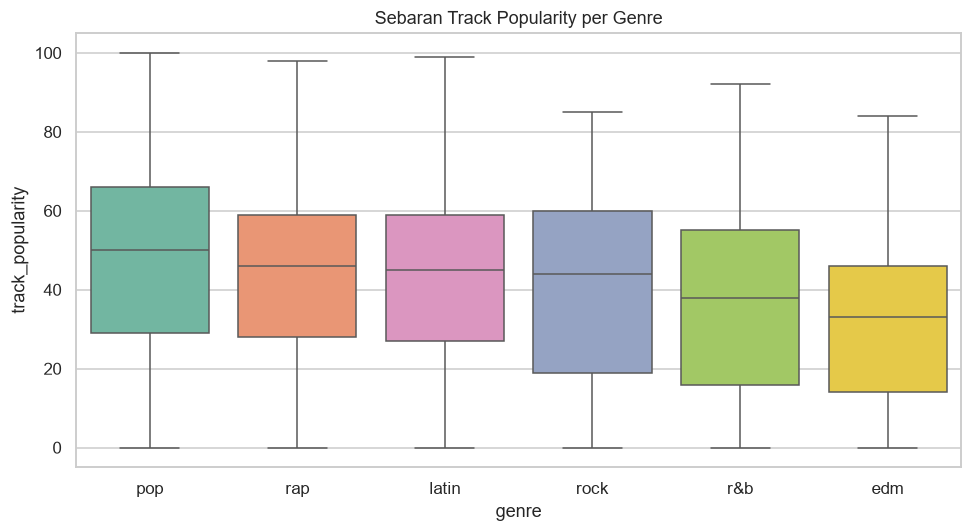

In [8]:
order = (df_clean.groupby("playlist_genre")["track_popularity"].median().sort_values(ascending=False).index)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="playlist_genre", y="track_popularity", order=order, hue="playlist_genre", palette="Set2", legend=False)
plt.title("Sebaran Track Popularity per Genre")
plt.xlabel("genre")
plt.ylabel("track_popularity")
plt.tight_layout()
plt.show()

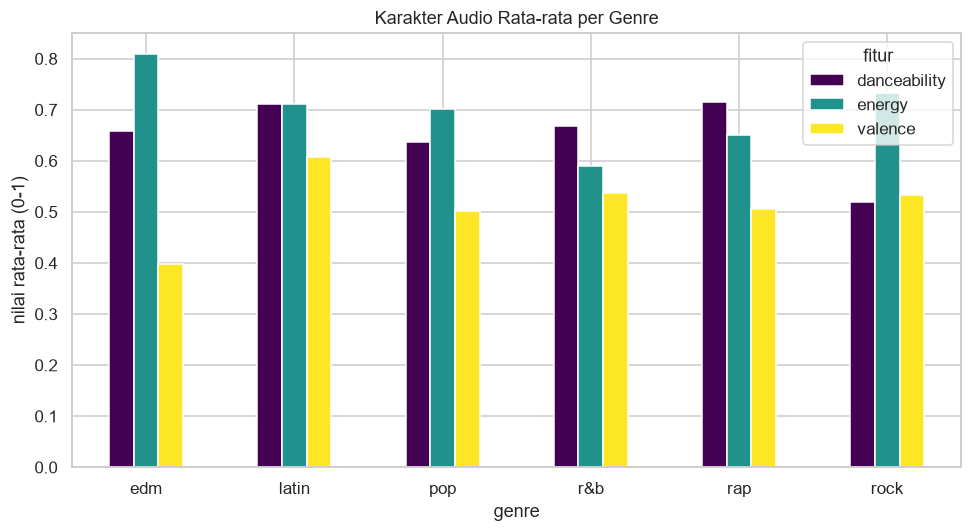

In [36]:
char = df_clean.groupby("playlist_genre")[["danceability", "energy", "valence"]].mean()
char.plot(kind="bar", figsize=(9, 5), colormap="viridis", edgecolor="white")
plt.title("Karakter Audio Rata-rata per Genre")
plt.xlabel("genre")
plt.ylabel("nilai rata-rata (0-1)")
plt.xticks(rotation=0)
plt.legend(title="fitur")
plt.tight_layout()
plt.show()

Dari boxplot, kotak (IQR) genre pop paling tinggi & panjang, artinya sebaran popularitasnya paling lebar, ini nyambung langsung ke pertanyaan 2.6. Dari bar chart, EDM energy-nya paling tinggi, rap danceabilitynya menonjol, dan valence (keceriaan) beda-beda tiap genre.

### 2.6 Genre dengan variansi popularitas tertinggi + arti bisnisnya

Variansi = s². Saya urutkan variansi `track_popularity` per genre, lalu plot biar gampang dibandingin.

In [10]:
var_pop = (df_clean.groupby("playlist_genre")["track_popularity"].var().sort_values(ascending=False).round(2))
print(var_pop)
print("\nGenre dengan variansi popularitas TERTINGGI:", var_pop.index[0], "(", var_pop.iloc[0], ")")

playlist_genre
pop      605.97
rock     587.07
r&b      559.94
latin    547.30
rap      518.27
edm      414.00
Name: track_popularity, dtype: float64

Genre dengan variansi popularitas TERTINGGI: pop ( 605.97 )


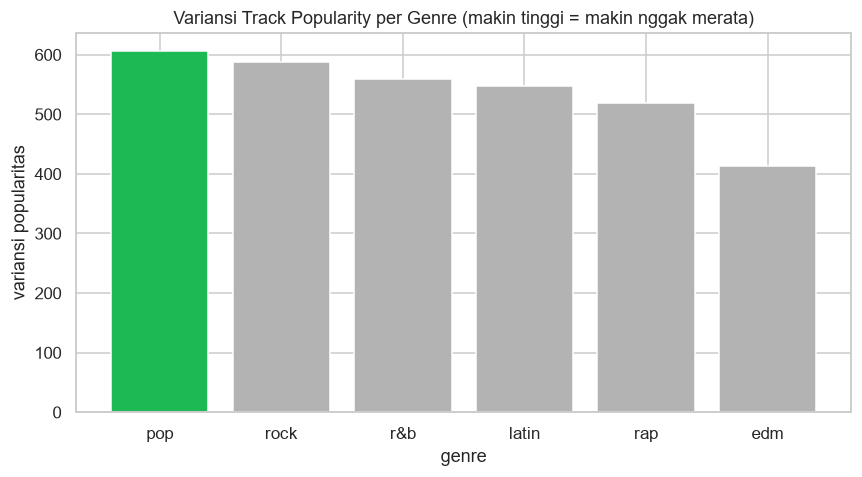

In [11]:
plt.figure(figsize=(8, 4.5))
colors = [SPOTIFY_GREEN if g == var_pop.index[0] else "#B3B3B3" for g in var_pop.index]
plt.bar(var_pop.index, var_pop.values, color=colors, edgecolor="white")
plt.title("Variansi Track Popularity per Genre (makin tinggi = makin nggak merata)")
plt.xlabel("genre")
plt.ylabel("variansi popularitas")
plt.tight_layout()
plt.show()

Genre dengan variansi popularitas paling tinggi (di dataset ini pop, yang saya highlight hijau) artinya adalah di dalam genre itu jaraknya jauh antara lagu mega hits dan lagu yang nyaris nggak didengerin. Popularitasnya nggak merata.

Buat startup rekomendasi konten, ini artinya genre pop itu high risk high reward. Kalau sistem asal nyodorin lagu pop, peluang ngasih lagu "flop" juga besar karena sebarannya lebar, jadi rekomendasi di genre ini butuh model yang lebih pintar milih (nggak bisa cuma "kasih lagu pop apa aja"). Sebaliknya genre dengan variansi kecil lebih "aman diprediksi" karena popularitas antar lagunya mirip-mirip.

### 2.7 10 artis dengan lagu terbanyak, apakah kuantitas = kualitas?

Cari 10 artis dengan jumlah track terbanyak, lalu di antara 10 itu lihat siapa yang mean `track_popularity` nya paling tinggi. Pertanyaan intinya adalah apakah "produktif" berarti "berkualitas"?

In [13]:
top10 = df_clean["track_artist"].value_counts().head(10)
print("10 artis dengan track terbanyak:")
print(top10)
sub = df_clean[df_clean["track_artist"].isin(top10.index)]
mean_pop_top10 = (sub.groupby("track_artist")["track_popularity"].mean().round(2).sort_values(ascending=False))
print("\nRata-rata popularitas di antara 10 artis tersebut:")
print(mean_pop_top10)

10 artis dengan track terbanyak:
track_artist
Queen                        130
Martin Garrix                 87
Don Omar                      84
David Guetta                  81
Dimitri Vegas & Like Mike     68
Hardwell                      68
Drake                         68
The Chainsmokers              66
Logic                         65
Guns N' Roses                 63
Name: count, dtype: int64

Rata-rata popularitas di antara 10 artis tersebut:
track_artist
David Guetta                 49.37
The Chainsmokers             49.23
Queen                        42.40
Logic                        41.91
Drake                        41.81
Martin Garrix                41.40
Don Omar                     39.06
Hardwell                     36.32
Dimitri Vegas & Like Mike    36.22
Guns N' Roses                27.21
Name: track_popularity, dtype: float64


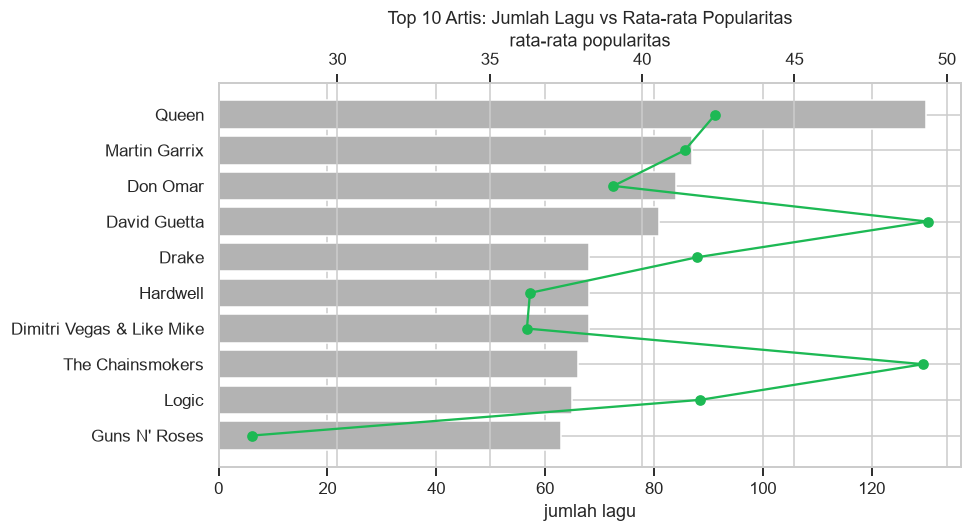

In [14]:
merge = pd.DataFrame({"jumlah_lagu": top10, "mean_pop": mean_pop_top10}).sort_values("jumlah_lagu", ascending=True)
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.barh(merge.index, merge["jumlah_lagu"], color="#B3B3B3", edgecolor="white", label="jumlah lagu")
ax1.set_xlabel("jumlah lagu")
ax2 = ax1.twiny()
ax2.plot(merge["mean_pop"], merge.index, "o-", color=SPOTIFY_GREEN, label="rata-rata popularitas")
ax2.set_xlabel("rata-rata popularitas")
plt.title("Top 10 Artis: Jumlah Lagu vs Rata-rata Popularitas")
fig.tight_layout()
plt.show()

Kelihatan dari plot, batang abu-abu (jumlah lagu) dan titik hijau (rata-rata popularitas) nggak searah. Yang jumlah track-nya paling banyak (Queen, 130 lagu) bukan yang rata-rata popularitasnya paling tinggi, yang tertinggi malah David Guetta. Jadi di dataset ini volume tidak otomatis = kualitas.

Artis produktif pasti punya lagu hits sekaligus banyak lagu B-side / album track yang kurang dikenal, jadi rata-ratanya ketarik turun. Pelajaran buat sistem rekomendasi adalah jangan pakai "jumlah lagu artis" sebagai proxy kualitas.

### 2.8 Filter multi-kondisi

Cari lagu yang memenuhi semua syarat sekaligus: popularity > 70, danceability > 0.7, energy > 0.6, durasi < 240000 ms (4 menit). Ini kira-kira profil "lagu dance enerjik, populer, dan nggak kepanjangan".

In [15]:
mask = ((df_clean["track_popularity"] > 70) & (df_clean["danceability"] > 0.7) & (df_clean["energy"] > 0.6) & (df_clean["duration_ms"]< 240000))
hits = df_clean[mask]
print("Jumlah lagu yang lolos semua syarat:", len(hits))
print("\nGenre paling dominan di antara yang lolos:")
print(hits["playlist_genre"].value_counts())

Jumlah lagu yang lolos semua syarat: 579

Genre paling dominan di antara yang lolos:
playlist_genre
pop      193
latin    173
rap      141
r&b       42
edm       19
rock      11
Name: count, dtype: int64


Hasil analisis menunjukkan sekitar 579 lagu lolos, dan yang dominan yaitu genre pop. Cocok sama intuisi, kombinasi "populer + danceable + enerjik + durasi pendek" itu memang resep khas lagu pop radio-friendly. Ini juga jadi validasi silang dimana genre pop yang di 2.6 variansinya paling tinggi ternyata juga yang paling banyak "nembak" profil hits ini.

## Stage 3, Analisis NumPy

Di stage ini saya keluar dari Pandas dan main di level array NumPy seperti normalisasi, korelasi, dan boolean masking. Semua vectorised (nggak boleh loop Python, nggak boleh sklearn).

### 3.9 Ambil 9 fitur audio, lalu min-max scaling [0,1] (vectorised)

Terdapat 9 fitur yaitu danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo. Karena skalanya beda-beda jauh (tempo ratusan, loudness minus, sisanya 0–1), saya normalisasi ke [0,1] dengan rumus min-max: `(x - min) / (max - min)`. Kunci vectorised-nya: `min`/`max` dihitung `axis=0` (per kolom), lalu broadcasting.

In [16]:
feat_cols = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
X = df_clean[feat_cols].to_numpy(dtype=float)
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

print("Shape array fitur:", X.shape)
print("Min tiap kolom setelah normalisasi:", X_norm.min(axis=0).round(3))
print("Max tiap kolom setelah normalisasi:", X_norm.max(axis=0).round(3))
assert np.allclose(X_norm.min(axis=0), 0) and np.allclose(X_norm.max(axis=0), 1)
print("OK: semua fitur ternormalisasi ke [0,1]")

Shape array fitur: (28356, 9)
Min tiap kolom setelah normalisasi: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max tiap kolom setelah normalisasi: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
OK: semua fitur ternormalisasi ke [0,1]


### 3.10 Matriks korelasi 9 fitur (np.corrcoef) + interpretasi musikal

`np.corrcoef` butuh `rowvar=False` supaya kolom dianggap sebagai variabel. Lalu saya cari pasangan dengan korelasi positif tertinggi dan paling negatif (ambil segitiga atas biar nggak double-count dan nggak kena diagonal yang selalu 1). Setelah itu saya plot sebagai heatmap biar polanya kebaca sekilas.

In [17]:
corr = np.corrcoef(X_norm, rowvar=False)
corr_df = pd.DataFrame(corr, index=feat_cols, columns=feat_cols).round(3)
print(corr_df)
iu = np.triu_indices(len(feat_cols), k=1)
pairs = [(feat_cols[i], feat_cols[j], corr[i, j]) for i, j in zip(*iu)]
pairs.sort(key=lambda p: p[2])
print("\nKorelasi PALING NEGATIF :", pairs[0])
print("Korelasi POSITIF TERTINGGI:", pairs[-1])

                  danceability  energy  loudness  speechiness  acousticness  \
danceability             1.000  -0.081     0.015        0.183        -0.029   
energy                  -0.081   1.000     0.682       -0.029        -0.546   
loudness                 0.015   0.682     1.000        0.013        -0.372   
speechiness              0.183  -0.029     0.013        1.000         0.025   
acousticness            -0.029  -0.546    -0.372        0.025         1.000   
instrumentalness        -0.002   0.024    -0.154       -0.108        -0.003   
liveness                -0.127   0.164     0.082        0.059        -0.075   
valence                  0.334   0.150     0.050        0.065        -0.019   
tempo                   -0.185   0.152     0.097        0.033        -0.114   

                  instrumentalness  liveness  valence  tempo  
danceability                -0.002    -0.127    0.334 -0.185  
energy                       0.024     0.164    0.150  0.152  
loudness            

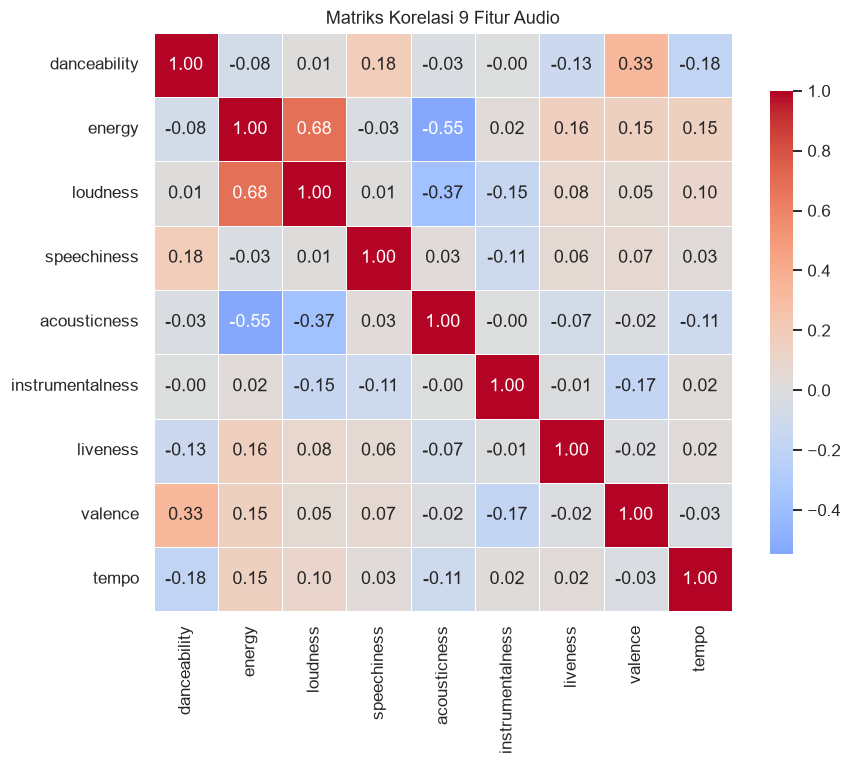

In [18]:
plt.figure(figsize=(8.5, 7))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriks Korelasi 9 Fitur Audio")
plt.tight_layout()
plt.show()

Interpretasi musikalnya adalah sebagai berikut.

- Positif tertinggi yaitu energy ↔ loudness (~0.68), kotak merah paling pekat di heatmap. Lagu yang direkam keras (loud) hampir selalu terasa berenergi. Volume dan energi memang jalan bareng, lagu rock/EDM yang "nendang" pasti loud sekaligus high energy.
- Korelasi paling negatif yaitu energy ↔ acousticness (~−0.55), kotak biru paling pekat. Makin akustik sebuah lagu (gitar/piano tanpa banyak produksi elektronik), makin kalem dan low energy. Lagu akustik dan lagu bertenaga itu dua kutub berlawanan.

Dua pasangan ini korelasinya cukup kuat, jadi ada redundansi info. Kalau nanti bikin model, `energy` dan `loudness` agak "cerita hal yang sama", bisa dipertimbangkan pas feature selection.

### 3.11 Boolean masking untuk lagu ber-energy di atas μ + σ

Pakai boolean masking NumPy murni (bukan filter Pandas). Ambil lagu yang energy-nya > mean + 1 standar deviasi, lalu bandingkan rata-rata popularitasnya dengan populasi keseluruhan.

In [19]:
energy = df_clean["energy"].to_numpy(dtype=float)
pop    = df_clean["track_popularity"].to_numpy(dtype=float)
mu, sigma = energy.mean(), energy.std()
threshold = mu + sigma
hi_mask = energy > threshold
print(f"Threshold energy (mu + sigma): {threshold:.3f}")
print(f"Jumlah lagu high-energy: {hi_mask.sum()}")
print(f"Mean popularitas high-energy: {pop[hi_mask].mean():.2f}")
print(f"Mean popularitas keseluruhan: {pop.mean():.2f}")
print(f"Selisih: {pop[hi_mask].mean() - pop.mean():.2f}")

Threshold energy (mu + sigma): 0.882
Jumlah lagu high-energy: 4853
Mean popularitas high-energy: 34.03
Mean popularitas keseluruhan: 39.33
Selisih: -5.30


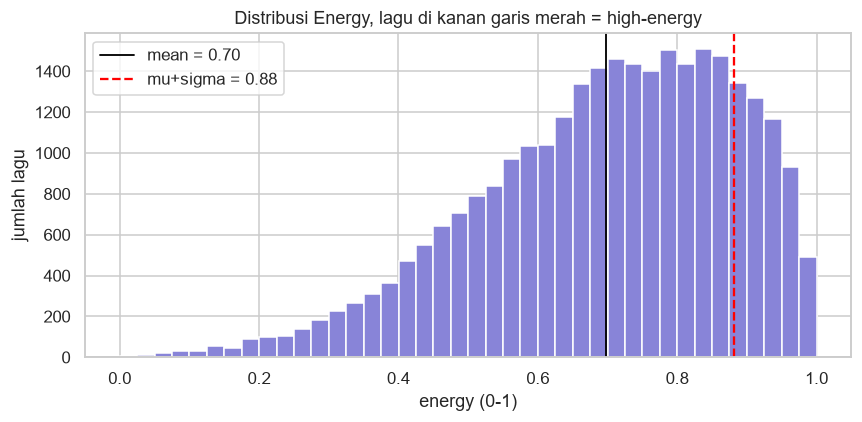

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(energy, bins=40, color="#8884d8", edgecolor="white")
plt.axvline(mu, color="black", linestyle="-", linewidth=1.2, label=f"mean = {mu:.2f}")
plt.axvline(threshold, color="red", linestyle="--", linewidth=1.5, label=f"mu+sigma = {threshold:.2f}")
plt.title("Distribusi Energy, lagu di kanan garis merah = high-energy")
plt.xlabel("energy (0-1)")
plt.ylabel("jumlah lagu")
plt.legend()
plt.tight_layout()
plt.show()

Temuan yang agak counter-intuitive adalah lagu super-enerjik (yang di kanan garis merah) justru rata-rata popularitasnya lebih rendah (~34 vs ~39 keseluruhan). Jadi "lagu makin nendang" bukan berarti "makin populer". Kemungkinan besar karena banyak lagu high energy ada di sub genre niche (hardcore EDM, metal) yang pendengarnya spesifik, bukan mainstream. Asumsi awal "energi tinggi = disukai banyak orang" ternyata nggak didukung data.

## Stage 4, Dokumentasi dan Refleksi Tool AI

### 4.12 Docstring dibantu AI coding tool + evaluasi

Saya butuh docstring buat dua fungsi yang saya pakai di Bonus 1 & 2 (`artist_fingerprint` dan `cosine_similarity`), lalu saya minta draftnya dulu ke Gemini dan saya koreksi manual.

Prompt yang saya kasih adalah sebagai berikut.

> "Write a NumPy-style docstring for this Python function. It takes a Pandas DataFrame and an artist name, filters rows where the column `track_artist` equals that name, and returns the mean of 9 audio-feature columns as a NumPy array of shape (9,). Include a one-line summary, Parameters, and Returns. Keep it concise."

Reaksi saya pas lihat outputnya yaitu draft-nya lumayan buat kerangka, dan format Parameters/Returns-nya udah bener. Tapi saya nggak langsung terima mentah-mentah karena ada dua hal yang ganjil yaitu (1) return type-nya ditulis "list", padahal jelas-jelas `np.ndarray` shape (9,), dan (2) dia over-explain, sempat nambahin bagian soal error handling padahal fungsinya belum saya kasih validasi apa-apa, jadi docstring-nya jadi "bohong" soal behavior, bagian itu saya buang.

Jadi kesimpulannya adalah saya modifikasi, bukan pakai as-is. Draft AI ngebantu ngehemat waktu ngetik boilerplate, tapi klaim teknisnya tetep harus saya cek sendiri. Ini persis kayak yang ditekankan di modul, AI itu co-pilot, bukan autopilot, dan saya yang tetep tanggung jawab atas tiap baris. Docstring versi final saya pasang langsung di fungsi `artist_fingerprint` di Bonus 1 (lihat bawah).

### 4.13 Tiga insight utama (bahasa awam)

Ditulis supaya orang non-teknis (misal tim bisnis / marketing) langsung ngerti tanpa istilah statistik, yaitu sebagai berikut.

1. Lagu yang paling "nendang" (energik) ternyata rata-rata bukan yang paling populer. Orang nggak otomatis suka lagu cuma karena kenceng dan enerjik, selera pasar lebih ke tengah-tengah, bukan yang ekstrem.

2. Artis yang paling rajin rilis lagu bukan berarti tiap lagunya laris. Contohnya artis dengan katalog terbanyak justru popularitas rata-ratanya kalah dari artis lain yang lagunya lebih sedikit tapi lebih "kena". Jadi jumlah ≠ mutu.

3. Genre pop itu paling "judi" dimana bisa mega-hits, bisa juga sepi peminat. Di genre ini jaraknya paling jauh antara lagu super populer dan lagu yang nyaris nggak didengar, jadi kalau mau rekomendasi lagu pop, sistemnya harus lebih hati-hati milih.

## Bonus 1, Artist Audio Fingerprint (cosine similarity manual)

Bikin `artist_fingerprint(df, artist_name)` yang balikin rata-rata 9 fitur audio si artis sebagai vektor NumPy, semacam "sidik jari suara" artis. Lalu bandingkan pakai cosine similarity yang diimplement dari rumusnya sendiri (tanpa sklearn/scipy):

$$\text{cosine\_similarity}(A,B) = \frac{A \cdot B}{\lVert A\rVert \, \lVert B\rVert}$$

In [23]:
def artist_fingerprint(df: pd.DataFrame, artist_name: str) -> np.ndarray:
    """Hitung sidik jari audio rata-rata seorang artis.

    Memfilter baris di mana track_artist == artist_name, lalu
    mengambil rata-rata 9 kolom fitur audio.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame lagu yang memuat kolom 'track_artist' dan 9 fitur audio.
    artist_name : str
        Nama artis yang dicari (harus persis sama dengan isi kolom).

    Returns
    -------
    np.ndarray
        Vektor rata-rata fitur, shape (9,), urut sesuai feat_cols.
    """
    sub = df[df["track_artist"] == artist_name]
    return sub[feat_cols].to_numpy(dtype=float).mean(axis=0)

def cosine_similarity(A: np.ndarray, B: np.ndarray) -> float:
    """Cosine similarity dua vektor, dihitung dari definisi matematisnya."""
    return float(np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B)))

def main_genre(name): return df_clean[df_clean["track_artist"] == name]["playlist_genre"].value_counts().index[0]
for a in ["Queen", "Martin Garrix", "David Guetta", "Drake", "Kanye West"]:
    print(f"{a:15s} | {df_clean['track_artist'].value_counts().get(a,0):3d} lagu | genre: {main_genre(a)}")

Queen           | 130 lagu | genre: rock
Martin Garrix   |  87 lagu | genre: edm
David Guetta    |  81 lagu | genre: edm
Drake           |  68 lagu | genre: rap
Kanye West      |  17 lagu | genre: rap


Catatan penting sebelum hitung yaitu jika cosine similarity dihitung dari fitur mentah, hasilnya nyaris 1.0 untuk semua pasangan. Kenapa? Karena `tempo` (nilainya ratusan) mendominasi magnitude vektor, bikin semua vektor "nunjuk arah yang hampir sama". Jadi saya normalisasi dulu tiap fingerprint pakai min-max global (pakai `X_min`/`X_max` dari Stage 3) baru dibandingkan. Ini pelajaran nyata kenapa scaling itu wajib.

In [27]:
def fingerprint_norm(name: str) -> np.ndarray:
    raw = artist_fingerprint(df_clean, name)
    return (raw - X_min) / (X_max - X_min)

pairs = [
    ("Martin Garrix", "David Guetta"),
    ("Drake", "Kanye West"),
    ("Queen", "Martin Garrix"),
]

print("Pasangan artis                    | cosine (mentah) | cosine (ternormalisasi) | genre")
print("-" * 92)
for a, b in pairs:
    raw_sim  = cosine_similarity(artist_fingerprint(df_clean, a), artist_fingerprint(df_clean, b))
    norm_sim = cosine_similarity(fingerprint_norm(a), fingerprint_norm(b))
    print(f"{a:14s} vs {b:14s}  |      {raw_sim:.4f}     |          {norm_sim:.4f}         | {main_genre(a)}/{main_genre(b)}")

Pasangan artis                    | cosine (mentah) | cosine (ternormalisasi) | genre
--------------------------------------------------------------------------------------------
Martin Garrix  vs David Guetta    |      1.0000     |          0.9849         | edm/edm
Drake          vs Kanye West      |      0.9999     |          0.9809         | rap/rap
Queen          vs Martin Garrix   |      0.9996     |          0.9527         | rock/edm


Interpretasi hasilnya adalah setelah dinormalisasi, dua artis se-genre (Garrix–Guetta di edm, Drake–Kanye di rap) similarity-nya lebih tinggi (~0.98) dibanding pasangan beda genre (Queen rock vs Garrix edm, ~0.95). Jadi jawabannya adalah ya, artis dari genre sama cenderung punya cosine similarity lebih tinggi, sidik jari audionya memang mirip. Tapi bedanya nggak ekstrem, karena banyak lagu modern lintas genre saling pinjam elemen produksi. Dan sekali lagi kelihatan tanpa normalisasi (kolom "mentah"), semua ~1.0 dan analisisnya jadi nggak berguna.

## Bonus 2, Genre Cluster Profile

Bikin profil audio tiap genre lalu ukur seberapa mirip/beda antar genre pakai jarak Euclidean, semuanya vectorised dengan broadcasting.

In [28]:
df_norm = df_clean.copy()
df_norm[feat_cols] = X_norm
genres = sorted(df_norm["playlist_genre"].unique())
centroids = np.vstack([df_norm[df_norm["playlist_genre"] == g][feat_cols].to_numpy().mean(axis=0) for g in genres])
print("Genre:", genres)
print("Shape centroid matrix:", centroids.shape)

Genre: ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']
Shape centroid matrix: (6, 9)


In [29]:
diff = centroids[:, None, :] - centroids[None, :, :]
dist = np.sqrt((diff ** 2).sum(axis=2))
dist_df = pd.DataFrame(dist, index=genres, columns=genres).round(3)
print("Matriks jarak antar-genre (0 = identik):")
print(dist_df)

Matriks jarak antar-genre (0 = identik):
         edm  latin    pop    r&b    rap   rock
edm    0.000  0.341  0.261  0.399  0.315  0.291
latin  0.341  0.000  0.140  0.163  0.164  0.230
pop    0.261  0.140  0.000  0.169  0.168  0.139
r&b    0.399  0.163  0.169  0.000  0.155  0.257
rap    0.315  0.164  0.168  0.155  0.000  0.273
rock   0.291  0.230  0.139  0.257  0.273  0.000


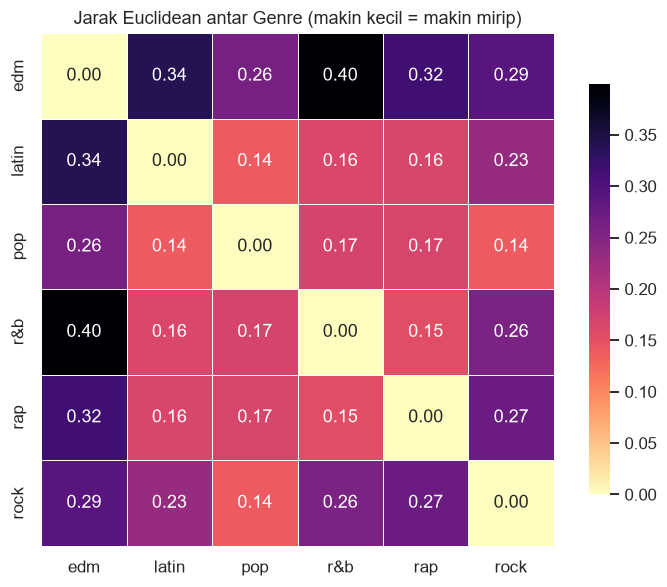

In [30]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="magma_r", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Jarak Euclidean antar Genre (makin kecil = makin mirip)")
plt.tight_layout()
plt.show()

In [31]:
iu = np.triu_indices(len(genres), k=1)
gpairs = [(genres[i], genres[j], dist[i, j]) for i, j in zip(*iu)]
gpairs.sort(key=lambda p: p[2])
print("Dua genre PALING MIRIP :", gpairs[0][0], "&", gpairs[0][1], f"(jarak {gpairs[0][2]:.3f})")
print("Dua genre PALING BEDA  :", gpairs[-1][0], "&", gpairs[-1][1], f"(jarak {gpairs[-1][2]:.3f})")

Dua genre PALING MIRIP : pop & rock (jarak 0.139)
Dua genre PALING BEDA  : edm & r&b (jarak 0.399)


In [33]:
def recommend_similar_genre(genre: str, top_k: int = 3) -> list:
    idx = genres.index(genre)
    order = np.argsort(dist[idx])
    return [genres[j] for j in order if j != idx][:top_k]

for g in genres:
    print(f"{g:6s} -> mirip dengan: {recommend_similar_genre(g)}")

edm    -> mirip dengan: ['pop', 'rock', 'rap']
latin  -> mirip dengan: ['pop', 'r&b', 'rap']
pop    -> mirip dengan: ['rock', 'latin', 'rap']
r&b    -> mirip dengan: ['rap', 'latin', 'pop']
rap    -> mirip dengan: ['r&b', 'latin', 'pop']
rock   -> mirip dengan: ['pop', 'latin', 'r&b']


Apakah cocok sama intuisi musik?

Dari heatmap kelihatan jelas dimana kotak paling terang (jarak besar) ada di pasangan edm ↔ r&b, dan itu logis, EDM enerjik/loud/sintetik sedangkan R&B smooth/mellow/low-energy. Dua kutub yang beda jelas.

Yang agak nabrak intuisi awal, pasangan paling mirip melibatkan pop yang deket ke banyak genre. Pop itu genre "tengah" yang minjem elemen dari mana-mana, jadi centroid nya emang dekat ke banyak genre. Jadi menurut saya hasilnya konsisten, cuma maksa saya sadar bahwa "profil rata-rata" genre bisa beda dari stereotipe lagu paling ikoniknya.

## Bonus 3, Reusable Analysis Class dengan Dokumentasi AI

Refactor seluruh analisis jadi satu class `SpotifyAnalyzer` biar bisa dipakai ulang. Docstring tiap method saya bantu draft pakai AI lalu saya revisi (catatan di akhir).

In [34]:
from typing import Dict, List
import json

class SpotifyAnalyzer:
    """Pipeline EDA ringkas untuk dataset Spotify Songs.

    Memuat data dari URL, melakukan dedup per track_id, lalu
    menyediakan beberapa method analisis dan satu generate_report()
    yang merangkum semua insight ke dalam dictionary siap-JSON.
    """

    FEATURES: List[str] = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

    def __init__(self, url: str) -> None:
        raw = pd.read_csv(url)
        self.df: pd.DataFrame = raw.drop_duplicates(subset=["track_id"]).reset_index(drop=True)

    def genre_popularity_stats(self) -> pd.DataFrame:
        return self.df.groupby("playlist_genre")["track_popularity"].agg(["mean", "std", "median"]).round(3)

    def highest_variance_genre(self) -> str:
        return self.df.groupby("playlist_genre")["track_popularity"].var().idxmax()

    def normalized_features(self) -> np.ndarray:
        M = self.df[self.FEATURES].to_numpy(dtype=float)
        return (M - M.min(axis=0)) / (M.max(axis=0) - M.min(axis=0))

    def feature_correlation(self) -> pd.DataFrame:
        c = np.corrcoef(self.normalized_features(), rowvar=False)
        return pd.DataFrame(c, index=self.FEATURES, columns=self.FEATURES).round(3)

    def high_energy_vs_overall(self) -> Dict[str, float]:
        e = self.df["energy"].to_numpy(float)
        p = self.df["track_popularity"].to_numpy(float)
        mask = e > (e.mean() + e.std())
        return {"high_energy_mean_pop": round(float(p[mask].mean()), 2), "overall_mean_pop": round(float(p.mean()), 2)}

    def generate_report(self) -> Dict:
        top_artist_counts = self.df["track_artist"].value_counts().head(10)
        sub = self.df[self.df["track_artist"].isin(top_artist_counts.index)]
        best_artist = sub.groupby("track_artist")["track_popularity"].mean().idxmax()
        corr = self.feature_correlation().to_numpy()
        iu = np.triu_indices(len(self.FEATURES), k=1)
        cp = [(self.FEATURES[i], self.FEATURES[j], corr[i, j]) for i, j in zip(*iu)]
        cp.sort(key=lambda x: x[2])

        return {
            "n_tracks": int(len(self.df)),
            "n_genres": int(self.df["playlist_genre"].nunique()),
            "genre_terbanyak": self.df["playlist_genre"].value_counts().index[0],
            "genre_variansi_pop_tertinggi": self.highest_variance_genre(),
            "artis_paling_produktif": top_artist_counts.index[0],
            "artis_paling_populer_dari_top10": best_artist,
            "korelasi_positif_tertinggi": [cp[-1][0], cp[-1][1], round(float(cp[-1][2]), 3)],
            "korelasi_paling_negatif": [cp[0][0], cp[0][1], round(float(cp[0][2]), 3)],
            "high_energy_vs_overall": self.high_energy_vs_overall(),
        }

analyzer = SpotifyAnalyzer(URL)
report = analyzer.generate_report()
print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "n_tracks": 28356,
  "n_genres": 6,
  "genre_terbanyak": "rap",
  "genre_variansi_pop_tertinggi": "pop",
  "artis_paling_produktif": "Queen",
  "artis_paling_populer_dari_top10": "David Guetta",
  "korelasi_positif_tertinggi": [
    "energy",
    "loudness",
    0.682
  ],
  "korelasi_paling_negatif": [
    "energy",
    "acousticness",
    -0.546
  ],
  "high_energy_vs_overall": {
    "high_energy_mean_pop": 34.03,
    "overall_mean_pop": 39.33
  }
}


Buat class ini saya pakai AI lagi buat generate docstring tiap method, tapi kali ini saya belajar dari pengalaman di Stage 4, lalu saya kasih instruksi yang lebih ketat dari awal biar AInya nggak ngarang.

Prompt yang saya pakai adalah sebagai berikut.

> "Generate concise one-line docstrings (Google style) for each method of this Python class. Base the description strictly on what the code actually does, do not invent parameters or behavior. Here is the class: [paste kode]"

Evaluasi saya menunjukkan bahwa karena saya udah nambahin "jangan ngarang parameter/behavior", hasilnya jauh lebih bersih, nggak ada lagi `Raises: ValueError` gadungan yang biasanya suka dia tambahin sendiri padahal saya nggak nulis validasi apa pun. Buat method sederhana, docstring-nya bisa saya pakai hampir langsung. Tapi khusus `generate_report()` tetep saya rombak manual, karena AI cuma ngasih "returns a dictionary" yang terlalu generik, saya mau docstring-nya nyebut bahwa output-nya siap di-serialisasi ke JSON, karena itu poin pentingnya.

Kesimpulannya adalah draft AI dipakai sebagian, lalu direvisi di bagian yang butuh spesifik. Makin jelas instruksi di prompt, makin sedikit yang harus saya betulin, ini juga sejalan sama prinsip "makin spesifik prompt makin berguna output"-nya di modul. Tapi ujungnya tetep saya yang baca & tanggung jawab tiap baris.